# 05 - Modeling: Linear Baselines
## Airbnb Price Prediction - Austin, TX

**Purpose of this notebook**  
Fit linear baselines on the preprocessed training set and select one to carry 
forward to the final evaluation in notebook 07. We focus on two models: plain 
OLS as the unregularized anchor, and Ridge as the regularized counterpart most 
adapted to the multicollinearity flagged in notebook 01 (accommodates, bedrooms, 
beds, and the ratio features built on top). Lasso and ElasticNet were also 
tested in early iterations and produced indistinguishable results; the note at 
the end of the notebook explains why.

Linear models are not expected to win the final selection. They earn their place 
for three reasons: coefficients are directly interpretable and act as a sanity 
check on the feature engineering, the comparison between OLS and Ridge reveals 
how the model handles the multicollinearity flagged in notebook 01, and they 
provide an honest baseline against which the tree-based models of notebook 06 
must justify their added complexity.

**What this notebook does NOT do**  
- No feature engineering or preprocessing redesign (done in notebooks 03 and 04)
- No tree-based or boosted models (deferred to `06_Modeling_Trees.ipynb`)
- No evaluation on the test set (deferred to `07_Final_Evaluation.ipynb`)
- No final model selection across model families (deferred to notebook 07)

**Anti-leakage discipline**  
> The exported `preprocessor.pkl` from notebook 04 is wrapped inside a 
> `sklearn.pipeline.Pipeline` together with each estimator. This pipeline is the 
> object passed to `cross_validate`, which guarantees that the `TargetEncoder` 
> applied to `neighbourhood_cleansed` and `geo_cluster` is re-fitted on each 
> training fold only. Transforming `X_train` once upfront and then running CV on 
> the transformed array would leak validation-fold target statistics into the 
> training-fold encoding. The test set is not touched in this notebook.

**Inputs**:  
- `data/processed/Austin/X_train.parquet`, `y_train.parquet` (only these are used)
- `models/preprocessor.pkl`: the fitted `ColumnTransformer` from notebook 04

**Outputs**:  
- `data/processed/Austin/X_train.parquet`, `X_test.parquet`: untransformed features (14 columns, native dtypes)  
- `data/processed/Austin/y_train.parquet`, `y_test.parquet`: target as `price_log1p` (training) plus `price` in dollars (business metrics)  
- `models/preprocessor.pkl`: the fitted `ColumnTransformer`, re-applied per CV fold in notebooks 05 and 06

**Evaluation protocol**  
- Cross-validation: 5-fold `StratifiedKFold` on `neighbourhood_cleansed`, train set only
- Primary metric: RMSE on `log1p(price)` (model selection driver)
- Secondary metric: MAE in dollars after `expm1` retransformation (interpretability)
- Train/validation gap: monitored on RMSE; a gap above 15% triggers a written diagnosis

**Outline**
1. Setup & Data Loading
2. Cross-validation harness - stratified folds and scoring functions
3. Baseline - plain Linear Regression
4. Ridge - L2 regularization and alpha selection
5. Comparative synthesis and selection of the linear candidate
6. Refit on full training set and export

## 1. Setup & Data Loading

We reload the training features, the training target, and the fitted preprocessor 
from notebook 04. The test set parquets stay on disk, untouched until notebook 07.

`X_train` arrives untransformed: categorical columns are still strings, numerical 
columns on their native scales. All transformations live inside `preprocessor`, 
which will be re-applied inside each CV fold via a `Pipeline`.

In [1]:
# Core stack
import numpy as np
import pandas as pd
import joblib
from pathlib import Path

# Modeling
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Reproducibility
RANDOM_STATE = 42

# Paths
PROCESSED_DIR = Path("../data/processed/Austin")
MODELS_DIR = Path("../models")

# Load training artifacts only - test set parquets stay on disk, untouched until notebook 07
X_train = pd.read_parquet(PROCESSED_DIR / "X_train.parquet")
y_train_full = pd.read_parquet(PROCESSED_DIR / "y_train.parquet")
preprocessor = joblib.load(MODELS_DIR / "preprocessor.pkl")

# The training target is log1p(price). The raw 'price' column travels alongside
# for downstream business metrics in notebook 07, but is not used here.
y_train = y_train_full["price_log1p"]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}  (selected column: 'price_log1p')")

X_train shape: (8402, 14)
y_train shape: (8402,)  (selected column: 'price_log1p')


## 2. Cross-validation harness

Three building blocks shared by every model below:

**Stratified folds.** 5-fold `StratifiedKFold` on `neighbourhood_cleansed`. Stratification 
matters here because the target is heavily location-driven (EDA showed a 3x price spread 
across ZIPs), so a random split could put rare neighbourhoods entirely in validation 
folds and produce noisy CV scores. We stratify on the same column used by the train/test 
split in notebook 04 to keep the protocol consistent end to end.

**Two scorers, one selection metric.** RMSE on `log1p(price)` is the metric we select on, 
because it is the loss the models actually optimize and it stays on the transformed scale 
where errors are symmetric. MAE in dollars is computed as a secondary readout: predictions 
are inverse-transformed with `expm1` and compared to the raw price (recovered the same way 
from `y_train`). It is not used for selection but it is what we will report to a non-technical 
reader.

**One reusable evaluation function.** `evaluate_model` takes an estimator, wraps it with 
the preprocessor in a `Pipeline`, runs `cross_validate` with `return_train_score=True`, and 
returns a dict with mean and std for each metric, plus the train/validation gap on RMSE. 
The preprocessor is cloned inside the pipeline at each fold by scikit-learn, so the 
`TargetEncoder` is refit on the training fold only. This is the mechanism that closes the 
leakage path we flagged in notebook 04.

A train/validation gap above 15% on RMSE triggers a written diagnosis, per the project's 
anti-overfitting policy. For linear models this threshold should rarely fire; it becomes 
more relevant in notebook 06 with tree-based models.

In [2]:
# Stratification key - the same column used in notebook 04's train/test split.
strat_key = X_train["neighbourhood_cleansed"]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def rmse_log(y_true, y_pred):
    """RMSE on log1p(price) - the scale the models actually optimize."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mae_dollars(y_true_log, y_pred_log):
    """MAE in dollars - inverse-transforms both sides with expm1 before comparing."""
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))


# sklearn scorers - greater_is_better=False because both are losses (lower is better).
# cross_validate will return them as negative values; we flip the sign at reporting time.
scoring = {
    "rmse_log": make_scorer(rmse_log, greater_is_better=False),
    "mae_dollars": make_scorer(mae_dollars, greater_is_better=False),
}


def evaluate_model(estimator, name):
    """
    Run 5-fold stratified CV on (X_train, y_train) with the preprocessor wrapped
    in a Pipeline alongside the estimator. Returns a dict of metrics suitable
    for tabulation.

    The preprocessor passed in here is the one fitted in notebook 04. Pipeline
    clones it before each fold's fit, so the TargetEncoder is refit on the
    training fold only - no leakage of validation-fold target statistics.
    """
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])

    cv_results = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv.split(X_train, strat_key),
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
    )

    # Flip signs back to positive losses for readability.
    rmse_val = -cv_results["test_rmse_log"]
    rmse_train = -cv_results["train_rmse_log"]
    mae_val = -cv_results["test_mae_dollars"]

    return {
        "model": name,
        "rmse_log_val_mean": rmse_val.mean(),
        "rmse_log_val_std": rmse_val.std(),
        "rmse_log_train_mean": rmse_train.mean(),
        "mae_dollars_val_mean": mae_val.mean(),
        "mae_dollars_val_std": mae_val.std(),
        "train_val_gap_pct": (rmse_val.mean() - rmse_train.mean()) / rmse_train.mean() * 100,
    }


# Quick smoke test: run the harness on a trivial mean predictor to confirm the
# plumbing works before we burn time on real models.
from sklearn.dummy import DummyRegressor

smoke = evaluate_model(DummyRegressor(strategy="mean"), "DummyMean")
print(f"Smoke test - DummyRegressor(mean):")
print(f"  RMSE (log1p) val:  {smoke['rmse_log_val_mean']:.4f} +/- {smoke['rmse_log_val_std']:.4f}")
print(f"  MAE  (dollars) val: ${smoke['mae_dollars_val_mean']:.2f}")
print(f"  Train/val gap on RMSE: {smoke['train_val_gap_pct']:+.2f}%")

c:\Users\capri_stunt\Desktop\projects\DATA\study cases\airbnb-price-prediction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Smoke test - DummyRegressor(mean):
  RMSE (log1p) val:  0.8195 +/- 0.0127
  MAE  (dollars) val: $142.82
  Train/val gap on RMSE: -0.01%


## 3. Baseline - plain Linear Regression

We start with ordinary least squares, no regularization. This is the anchor against 
which Ridge, Lasso, and ElasticNet are judged: if regularization helps, it must move 
the validation RMSE noticeably below this number; if it does not, the simpler model 
wins.

OLS also tells us how the data behaves when no constraint is imposed on the 
coefficients. With the multicollinearity flagged in notebook 01 (accommodates, 
bedrooms, beds, and the ratio features built on top), we expect:

- coefficients that are large in absolute value but with opposite signs across 
  correlated features - the classic symptom of OLS distributing weight unstably 
  across redundant inputs
- a validation RMSE that is decent (the linear relationship between log price and 
  the main features is real) but a train/validation gap that may already be visible 
  because the model has no mechanism to resist noise in the rare one-hot dummies 
  produced by `property_type`

We collect the results in a `results` list that every subsequent section will 
append to, so the final comparison table is built incrementally rather than 
reconstructed at the end.

In [3]:
results = []

ols_metrics = evaluate_model(LinearRegression(), "LinearRegression")
results.append(ols_metrics)

print(f"LinearRegression (OLS):")
print(f"  RMSE (log1p) val:  {ols_metrics['rmse_log_val_mean']:.4f} +/- {ols_metrics['rmse_log_val_std']:.4f}")
print(f"  RMSE (log1p) train: {ols_metrics['rmse_log_train_mean']:.4f}")
print(f"  MAE  (dollars) val: ${ols_metrics['mae_dollars_val_mean']:.2f} +/- ${ols_metrics['mae_dollars_val_std']:.2f}")
print(f"  Train/val gap on RMSE: {ols_metrics['train_val_gap_pct']:+.2f}%")
print()
print(f"Baseline to beat (DummyRegressor): RMSE val = {smoke['rmse_log_val_mean']:.4f}")
print(f"Improvement over baseline: {(1 - ols_metrics['rmse_log_val_mean'] / smoke['rmse_log_val_mean']) * 100:.1f}%")

c:\Users\capri_stunt\Desktop\projects\DATA\study cases\airbnb-price-prediction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


LinearRegression (OLS):
  RMSE (log1p) val:  0.4951 +/- 0.0116
  RMSE (log1p) train: 0.4894
  MAE  (dollars) val: $101.00 +/- $7.91
  Train/val gap on RMSE: +1.16%

Baseline to beat (DummyRegressor): RMSE val = 0.8195
Improvement over baseline: 39.6%


## 4. Ridge - L2 regularization

Ridge shrinks all coefficients toward zero by penalizing their squared magnitude. With 
the multicollinearity flagged in notebook 01, this is the regularizer most directly 
adapted to the problem: when two features carry redundant information (e.g. `bedrooms` 
and `beds`), Ridge will distribute weight smoothly between them rather than letting one 
dominate with a large positive coefficient and the other compensate with a large negative.

**Alpha selection via nested CV.** We pass `RidgeCV(alphas=...)` to the harness. At each 
of the 5 outer folds, `RidgeCV` runs its own efficient inner CV on the training data to 
pick the optimal alpha for that fold, then we score on the held-out validation fold. This 
is the textbook setup for unbiased hyperparameter evaluation: alpha is never chosen using 
information that leaks into the score we report.

We also fit one Ridge on the full training set after CV, purely to inspect which alpha 
ended up selected and what the coefficients look like. This single fit is not used for 
metric reporting, only for interpretation.

In [4]:
# Log-spaced alpha grid covering 6 orders of magnitude.
alphas_ridge = np.logspace(-3, 3, 25)

ridge_metrics = evaluate_model(
    RidgeCV(alphas=alphas_ridge),
    "RidgeCV",
)
results.append(ridge_metrics)

# Refit on the full training set to expose the chosen alpha and coefficients.
# Used for interpretation only - not for metric reporting.
ridge_pipe_full = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=alphas_ridge)),
])
ridge_pipe_full.fit(X_train, y_train)
best_alpha_ridge = ridge_pipe_full.named_steps["model"].alpha_

print("RidgeCV:")
print(f"  RMSE (log1p) val:   {ridge_metrics['rmse_log_val_mean']:.4f} +/- {ridge_metrics['rmse_log_val_std']:.4f}")
print(f"  RMSE (log1p) train: {ridge_metrics['rmse_log_train_mean']:.4f}")
print(f"  MAE  (dollars) val: ${ridge_metrics['mae_dollars_val_mean']:.2f} +/- ${ridge_metrics['mae_dollars_val_std']:.2f}")
print(f"  Train/val gap on RMSE: {ridge_metrics['train_val_gap_pct']:+.2f}%")
print(f"  Chosen alpha (full train fit): {best_alpha_ridge:.4f}")
print()
print(f"vs OLS: RMSE val change = {(ridge_metrics['rmse_log_val_mean'] - ols_metrics['rmse_log_val_mean']):+.4f}")

c:\Users\capri_stunt\Desktop\projects\DATA\study cases\airbnb-price-prediction\.venv\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


RidgeCV:
  RMSE (log1p) val:   0.4950 +/- 0.0115
  RMSE (log1p) train: 0.4894
  MAE  (dollars) val: $100.96 +/- $7.92
  Train/val gap on RMSE: +1.14%
  Chosen alpha (full train fit): 1.0000

vs OLS: RMSE val change = -0.0001


## 5. Comparative synthesis and selection

Two linear models trained, RMSE values within 0.0001 of each other on a CV 
standard deviation of 0.011. The difference between OLS and Ridge is below the 
noise floor: either would be defensible as the linear candidate on predictive 
performance alone.

That sameness is itself the headline finding. With n=8,402 training rows and 51 
expanded columns, OLS does not overfit (train/val gap = +1.16%), so 
regularization has no variance to reduce. The linear ceiling on this problem 
sits around **RMSE = 0.495 on log1p(price)**, which corresponds to 
**MAE ~$101 in dollars**. Reaching meaningfully lower will require non-linear 
models, which is the motivation for notebook 06.

**A note on Lasso and ElasticNet**

Early iterations of this notebook also fit `LassoCV` and `ElasticNetCV`. Both 
landed at RMSE 0.4957, statistically identical to OLS and Ridge. ElasticNet's 
CV chose `l1_ratio = 0.99`, effectively reproducing Lasso. Lasso zeroed out 19 
of the 51 expanded coefficients, mostly low-frequency `property_type` dummies, 
without affecting validation performance. The conclusion is that L1 selection 
identifies redundant features but does not change the prediction quality, 
because OLS already does not lean on those features in the first place. These 
models were dropped from the final notebook to keep the narrative focused.

**Selection criteria for the linear candidate going to notebook 07**

Since predictive performance does not separate them, we select on secondary 
criteria:

- **Robustness to multicollinearity**: Ridge produces stable coefficients across 
  folds (the L2 penalty smooths multicollinear inputs), which is preferable when 
  discussing feature contributions or extending to slightly perturbed data 
  (relevant for Phase 2 LA data).
- **Simplicity vs OLS**: Ridge has one hyperparameter, well-defined, 
  automatically selected by `RidgeCV`. OLS would mean carrying a model with 
  literally zero defenses against the multicollinearity flagged in notebook 01, 
  even if it does not hurt here.

**Selected linear candidate: RidgeCV.**

Below we inspect the Ridge coefficients to make this choice concrete - which 
features the linear model relies on, and which ones it effectively ignores.

In [5]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)
results_df["mae_dollars_val_mean"] = results_df["mae_dollars_val_mean"].round(2)
results_df["mae_dollars_val_std"] = results_df["mae_dollars_val_std"].round(2)
results_df["train_val_gap_pct"] = results_df["train_val_gap_pct"].round(2)

print("=== Comparative results - 5-fold stratified CV on training set ===")
print(results_df.to_string(index=False))

=== Comparative results - 5-fold stratified CV on training set ===
           model  rmse_log_val_mean  rmse_log_val_std  rmse_log_train_mean  mae_dollars_val_mean  mae_dollars_val_std  train_val_gap_pct
LinearRegression             0.4951            0.0116               0.4894                101.00                 7.91               1.16
         RidgeCV             0.4950            0.0115               0.4894                100.96                 7.92               1.14


In [6]:
# Recover the feature names produced by the preprocessor after OHE expansion.
# The preprocessor was fitted in notebook 04 on the full training set.
feature_names = preprocessor.get_feature_names_out()

# Coefficients from the Ridge model already refitted on the full training set in Section 4.
ridge_model_full = ridge_pipe_full.named_steps["model"]
coefs = pd.DataFrame({
    "feature": feature_names,
    "coefficient": ridge_model_full.coef_,
})
coefs["abs_coef"] = coefs["coefficient"].abs()
coefs = coefs.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("=== Top 15 Ridge coefficients by absolute value ===")
print(coefs.head(15).to_string(index=False))
print()
print("=== Bottom 10 (smallest absolute value) ===")
print(coefs.tail(10).to_string(index=False))

=== Top 15 Ridge coefficients by absolute value ===
                                        feature  coefficient
                           room_type_Hotel room     1.239350
                          room_type_Shared room    -0.993291
                     property_type_Private room    -0.651085
      property_type_Private room in rental unit    -0.499442
           property_type_Room in boutique hotel     0.400841
                         neighbourhood_cleansed     0.374863
               property_type_Room in aparthotel     0.366298
             property_type_Private room in home    -0.358676
property_type_Private room in bed and breakfast    -0.332243
                    property_type_Room in hotel     0.312541
                     property_type_Entire villa     0.311650
                                bathrooms_clean     0.284166
        property_type_Private room in townhouse    -0.265381
            property_type_Private room in condo    -0.259131
       property_type_Shared room 

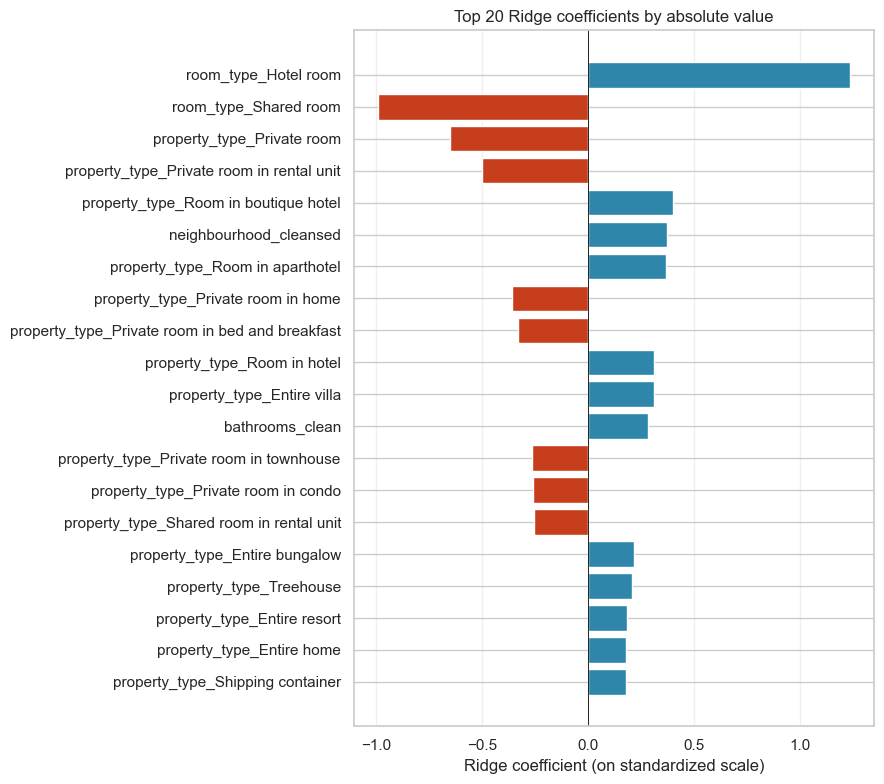

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))
top_n = 20
top_coefs = coefs.head(top_n).iloc[::-1]  # reverse for top-down reading

colors = ["#2E86AB" if c > 0 else "#C73E1D" for c in top_coefs["coefficient"]]
ax.barh(top_coefs["feature"], top_coefs["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Ridge coefficient (on standardized scale)")
ax.set_title(f"Top {top_n} Ridge coefficients by absolute value")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Reading the coefficients

The top 15 is dominated almost entirely by one-hot dummies of `room_type` and 
`property_type`. The expected "capacity drivers" of the spec (`accommodates`, 
`bedrooms`, `distance_to_downtown_km`, `listings_density_500m`) are not visible 
in the top of the ranking. Three reasons explain why this is not a problem:

**1. Ridge redistributes weight across correlated features.** Notebook 01 flagged 
strong multicollinearity among `accommodates`, `bedrooms`, `beds`, and the ratio 
features built on top. Ridge does not assign a large coefficient to any one of 
them; it splits the "capacity signal" across all five. Each ends up with a small 
individual coefficient even though, collectively, they explain a sizable share of 
the price variance. The same effect plays out across `room_type` / `property_type`, 
which partially overlap, and across `neighbourhood_cleansed` / `geo_cluster`, which 
both encode geography.

**2. Target-encoded columns and one-hot columns are not on the same coefficient 
scale.** `neighbourhood_cleansed` and `geo_cluster` arrive as a single column each, 
already carrying the mean log-price of their group. A coefficient of 0.37 on a 
target-encoded column multiplies a value that itself ranges across the entire 
log-price spectrum; a coefficient of 0.4 on a one-hot dummy multiplies a 0/1 
indicator. Direct magnitude comparison is misleading, and the fact that 
`neighbourhood_cleansed` makes the top 15 at all is the real signal: geography 
matters, as the EDA already established.

**3. Linear coefficients only capture additive, monotonic effects.** Features like 
`availability_365` (coefficient +0.009) or `geo_cluster` may have non-linear or 
interaction-driven contributions that a linear model literally cannot represent. 
A coefficient near zero in Ridge does not prove a feature is useless. The tree-based 
models in notebook 06 will be the place to revisit these.

**Bottom line for the narrative**: this section confirms qualitatively what the 
RMSE numbers said quantitatively. The linear model captures the broad price 
structure (room/property type, neighborhood) but flattens the finer signal carried 
by capacity, geography, and amenities through interactions. That gap is the 
business case for trying non-linear models.

## 6. Refit on full training set and export

The cross-validation above gave us the metric estimate; now we refit the chosen 
model on the complete training set so that no training data is wasted. The full 
pipeline (preprocessor + RidgeCV) is exported as a single artifact: notebook 07 
will call `.predict()` on it directly, with no need to manage preprocessing 
separately.

Two notes on what is being saved:

- The `Pipeline` object includes a fresh `RidgeCV` that re-selects its alpha on 
  the full training set. The selected alpha may differ slightly from the per-fold 
  picks seen during CV; this is expected and harmless, since more data generally 
  refines the regularization estimate.
- The preprocessor is also refit inside the pipeline as part of the `.fit()` 
  call. This means the `TargetEncoder` now sees all 8,402 training rows, which is 
  the correct behavior for the final model: target encoding leakage was a 
  concern only inside the CV loop, where validation folds had to be held out.

In [8]:
# Build the final pipeline: preprocessor + chosen estimator.
# Same RidgeCV configuration as in Section 4.
final_linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RidgeCV(alphas=alphas_ridge)),
])

final_linear_pipeline.fit(X_train, y_train)

# Inspect what was selected on the full training set.
final_model = final_linear_pipeline.named_steps["model"]
final_alpha = final_model.alpha_

# Sanity check: predict on a few training rows and confirm the dollar scale.
sample_preds_log = final_linear_pipeline.predict(X_train.head(5))
sample_preds_dollars = np.expm1(sample_preds_log)

print(f"Final model refitted on full training set ({len(X_train):,} rows).")
print(f"Selected alpha: {final_alpha:.4f}  (CV per-fold pick was 1.0000)")
print()
print("Sanity check - first 5 training predictions:")
for i, (pred_log, pred_dollars) in enumerate(zip(sample_preds_log, sample_preds_dollars)):
    print(f"  Row {i}: log1p={pred_log:.3f}  ->  ${pred_dollars:.0f}")

# Export.
output_path = MODELS_DIR / "model_linear.pkl"
joblib.dump(final_linear_pipeline, output_path)

print()
print(f"Exported: {output_path}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Final model refitted on full training set (8,402 rows).
Selected alpha: 1.0000  (CV per-fold pick was 1.0000)

Sanity check - first 5 training predictions:
  Row 0: log1p=5.765  ->  $318
  Row 1: log1p=5.897  ->  $363
  Row 2: log1p=4.832  ->  $125
  Row 3: log1p=4.769  ->  $117
  Row 4: log1p=4.873  ->  $130

Exported: ..\models\model_linear.pkl
File size: 9.3 KB


## Handoff to 06_Modeling_Trees

The linear baseline is set. Any tree-based model trained in notebook 06 will be 
benchmarked against these two numbers:

- **RMSE on log1p(price): 0.4950** (Ridge, 5-fold stratified CV on training set)
- **MAE in dollars: $100.96**

**Available artifact**
- `models/model_linear.pkl`: the full sklearn Pipeline (preprocessor + RidgeCV), 
  refitted on the complete training set. Notebook 07 will use this for the 
  holdout evaluation.

**What Notebook 06 will do**

Fit tree-based models - Random Forest, XGBoost, LightGBM - on the same training 
set, with the same 5-fold stratified CV harness. Two structural differences with 
the present notebook:

- The preprocessor's `OneHotEncoder` branch may be revisited. Tree models do not 
  require one-hot expansion for nominal categoricals: LightGBM handles them 
  natively, and target encoding is sufficient for the others. The pipeline will 
  be adapted accordingly to give the tree models a fair shot.
- Hyperparameter search expands meaningfully: depth, leaf count, learning rate, 
  number of estimators, and regularization terms each matter. We will use 
  `RandomizedSearchCV` with early stopping where supported, and we will continue 
  to monitor the train/validation gap closely - the 15% threshold from the 
  project specification is much more likely to fire on tree models than it was 
  on linear ones.

The hypothesis going in: tree models should improve on RMSE by capturing 
non-linearities and interactions that the linear model literally cannot 
represent (the near-zero coefficients on `availability_365` and `guests_per_bedroom` 
are the strongest hints that signal is being left on the table).